In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
train = pd.read_csv("../data/stock_7_train.csv")
test = pd.read_csv("../data/stock_7_test.csv")

print(f"Train: {train.shape[0]} rows, {train.shape[1]-1} features")
print(f"Test: {test.shape[0]} row")
train.head()

Train: 19999 rows, 25 features
Test: 1 row


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
0,1.402513,0.209976,2.593311,1.357551,-1.306500,-0.714442,0.047326,1.480742,0.592205,-0.180942,...,-1.368821,0.449648,0.337060,-1.277839,0.765275,-0.579439,0.719013,-2.145711,-1.700668,174.199186
1,0.421767,-0.347714,1.387006,0.318414,-0.153470,-0.229698,-1.933714,-0.124112,-0.203247,0.051417,...,-1.047037,-1.297922,-0.311753,1.138286,-2.739925,-0.127150,0.252049,1.869106,-0.649896,216.304382
2,-0.623742,-1.207320,0.954395,-0.198997,0.448556,0.139560,-0.733649,-0.420725,1.442714,-1.352541,...,-0.693362,-1.047938,-0.599430,2.242580,-0.333889,-0.987561,-1.934688,0.134801,-0.406266,210.385146
3,0.067309,-1.521668,-1.861041,-0.593892,2.796918,0.775388,1.392104,0.608417,0.205443,0.895392,...,1.692081,-0.208232,2.117692,0.573607,1.472445,1.178504,1.681704,0.918483,2.975310,174.834913
4,-1.684648,0.646631,-1.019983,-1.014805,-1.771459,-1.888588,-0.469923,-0.338140,-0.499531,-0.691399,...,0.018950,-0.763499,1.379789,1.071411,-0.600818,-2.122190,-1.426557,-1.308994,-1.336422,246.164719


In [3]:
train.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
count,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,...,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000
mean,-0.016949,0.002526,-0.006166,0.002534,-0.001797,0.003772,-0.004054,-0.000916,0.007748,0.004959,...,-0.002412,-0.002781,0.005687,-0.005365,-0.006873,0.007226,-0.003207,-0.015292,-0.002608,211.041822
std,1.003349,1.009951,0.998297,1.000384,1.004529,1.304942,1.001595,1.000344,1.002950,0.987719,...,1.003542,1.004341,0.999861,1.001240,1.280787,1.277086,1.281649,1.285697,1.283165,15.840565
min,-3.899658,-3.665091,-4.928238,-3.716643,-4.201818,-7.999824,-3.823946,-3.812636,-3.741949,-3.623327,...,-3.835065,-4.118189,-4.255280,-3.597768,-6.177769,-5.523909,-4.783672,-5.340536,-4.971102,80.000000
25%,-0.681725,-0.691529,-0.683711,-0.671260,-0.681234,-0.683756,-0.675375,-0.668564,-0.666659,-0.650527,...,-0.676262,-0.678037,-0.662389,-0.681057,-0.869995,-0.849370,-0.872187,-0.898339,-0.869304,205.646593
50%,-0.011631,0.000225,-0.007396,-0.008037,-0.000994,-0.001938,-0.003394,0.002429,0.002686,0.003541,...,-0.002349,0.003233,-0.000285,-0.007980,0.000682,0.005789,0.007606,-0.018372,0.004905,210.211415
75%,0.658639,0.695897,0.666200,0.668742,0.680957,0.701270,0.662331,0.670970,0.675769,0.675765,...,0.672720,0.671138,0.681036,0.667260,0.851669,0.863508,0.879873,0.852636,0.860644,215.609322
max,4.089614,4.218225,3.963285,4.673029,3.778811,7.987952,4.087923,3.784128,4.093223,4.075526,...,4.911258,4.679867,4.461654,4.085418,5.502100,5.378330,4.851455,5.080910,5.242372,400.000000


0 null columns


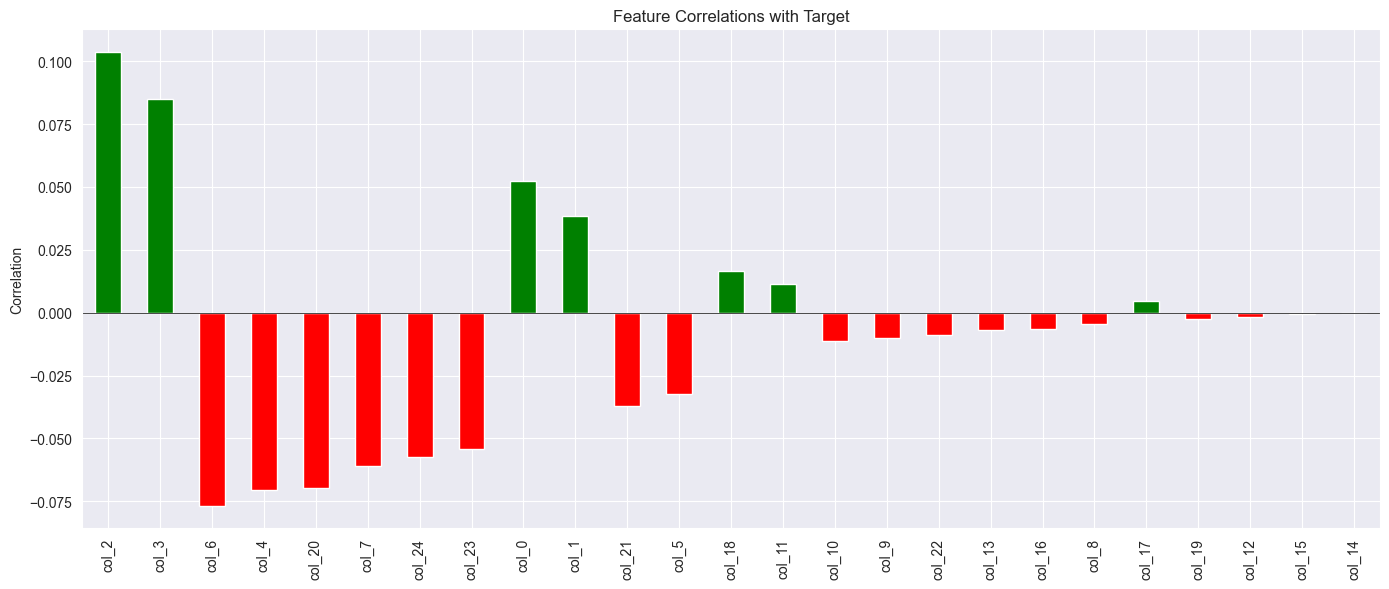

col_2     0.103645
col_3     0.085133
col_6    -0.076734
col_4    -0.070625
col_20   -0.069733
col_7    -0.061067
col_24   -0.057296
col_23   -0.054094
col_0     0.052173
col_1     0.038315
col_21   -0.036980
col_5    -0.032277
col_18    0.016762
col_11    0.011553
col_10   -0.011447
col_9    -0.010103
col_22   -0.009012
col_13   -0.006894
col_16   -0.006644
col_8    -0.004701
col_17    0.004594
col_19   -0.002466
col_12   -0.001545
col_15   -0.000546
col_14   -0.000224
Name: target, dtype: float64


In [4]:
print(train.isnull().any().sum(), "null columns")

corr = train.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(14, 6))
corr.plot(kind='bar', color=['red' if x < 0 else 'green' for x in corr])
plt.title('Feature Correlations with Target')
plt.ylabel('Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(corr)

In [5]:
y = train['target']

corrs = train.corr()['target'].drop('target')
strong = list(corrs[corrs.abs() > 0.05].index)
weak = list(corrs[corrs.abs() <= 0.05].index)

print(f"Strong features ({len(strong)}): {strong}")
print(f"Weak/noise features ({len(weak)}): {weak}")

models = {
    'Linear (all 25)': (LinearRegression(), train.drop('target', axis=1).columns.tolist()),
    'Linear (strong)': (LinearRegression(), strong),
    'Ridge a=1 (all)': (Ridge(alpha=1), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=10 (all)': (Ridge(alpha=10), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (all)': (Ridge(alpha=100), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (strong)': (Ridge(alpha=100), strong),
    'Mean baseline': (None, None),
}

print(f"\n{'Model':<25} {'CV RMSE':>10}")
print("-" * 37)

for name, (model, cols) in models.items():
    if model is None:
        rmse = y.std()
        print(f"{name:<25} {rmse:>10.2f}  (baseline)")
        continue
    X_m = train[cols]
    scores = cross_val_score(model, X_m, y, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name:<25} {rmse:>10.2f}")

Strong features (9): ['col_0', 'col_2', 'col_3', 'col_4', 'col_6', 'col_7', 'col_20', 'col_23', 'col_24']
Weak/noise features (16): ['col_1', 'col_5', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_21', 'col_22']

Model                        CV RMSE
-------------------------------------
Linear (all 25)                15.55
Linear (strong)                15.56
Ridge a=1 (all)                15.55
Ridge a=10 (all)               15.55
Ridge a=100 (all)              15.55
Ridge a=100 (strong)           15.56
Mean baseline                  15.84  (baseline)


In [6]:
X_all = train.drop('target', axis=1)
lr = LinearRegression().fit(X_all, y)
residuals = y - lr.predict(X_all)

print(f"Residual std: {residuals.std():.4f}")
print(f"Residual skew: {residuals.skew():.4f}")
print(f"Residual kurtosis: {residuals.kurtosis():.4f}")

# Quick nonlinearity check on top features
print("\nCorrelation of residuals with squared features:")
for col in ['col_2', 'col_3', 'col_6', 'col_4']:
    corr_sq = np.corrcoef(residuals, train[col]**2)[0, 1]
    print(f"  resid vs {col}²: {corr_sq:.4f}")

print(f"\nTargets at floor (80): {(y == 80).sum()}")
print(f"Targets at ceiling (400): {(y == 400).sum()}")

Residual std: 15.5242
Residual skew: 0.1657
Residual kurtosis: 6.9788

Correlation of residuals with squared features:
  resid vs col_2²: 0.0021
  resid vs col_3²: -0.0128
  resid vs col_6²: 0.0029
  resid vs col_4²: -0.0076

Targets at floor (80): 1
Targets at ceiling (400): 0


In [7]:
model = Ridge(alpha=100)
X_all = train.drop('target', axis=1)
model.fit(X_all, y)

print(f"Final model: Ridge(alpha=100) on all 25 features")
print(f"Train R²: {model.score(X_all, y):.4f}")
print(f"CV RMSE (honest): 15.55")

test_pred = model.predict(test)[0]

print(f"\nPredicted target: {test_pred:.4f}")

honest_sigma = 15.55
print(f"\n1 SD range: [{test_pred - honest_sigma:.2f}, {test_pred + honest_sigma:.2f}]")
print(f"2 SD range: [{test_pred - 2*honest_sigma:.2f}, {test_pred + 2*honest_sigma:.2f}]")

Final model: Ridge(alpha=100) on all 25 features
Train R²: 0.0395
CV RMSE (honest): 15.55

Predicted target: 214.6988

1 SD range: [199.15, 230.25]
2 SD range: [183.60, 245.80]
